# AEO A/B Test — RAG Pipeline Walkthrough

This notebook walks through the RAG pipeline step by step so you can see what's happening at each stage. Run the cells in order.

**Sections:**
1. Setup
2. Inspect the corpus — what does chunking produce?
3. What is an embedding? (making vectors concrete)
4. Retrieval — which chunks score highest for a query?
5. Side-by-side: Arm A vs Arm B retrieval
6. Full RAG answers — retrieval + generation together
7. Summary table across queries

## 1. Setup

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import yaml
from dotenv import load_dotenv

# Make repo root importable so `core` and `tasks` resolve correctly
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

load_dotenv(repo_root / ".env")

os.chdir(repo_root)   # all relative paths in config.yaml resolve from here

config = yaml.safe_load(open("config.yaml"))
print("Config loaded:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config loaded:
  domain: project management tools for small teams
  target_product_name: TaskFlow Pro
  answer_model: claude-haiku-4-5-20251001
  judge_model: claude-haiku-4-5-20251001
  embedding_model: all-MiniLM-L6-v2
  n_repeats: 5
  temperature: 0.7
  top_k: 3
  baseline_citation_rate: 0.3
  min_detectable_effect: 0.2
  alpha: 0.05
  power: 0.8
  n_distractors: 5
  n_queries: 40
  paths: {'variant_a': 'data/content/variant_a.md', 'variant_b': 'data/content/variant_b.md', 'distractors': 'data/content/distractors', 'queries': 'data/queries.json', 'results': 'data/results/results.csv'}


## 2. Build corpora and inspect chunks

Each corpus = our product doc + 5 distractor docs, all **split into paragraphs**.
The split is what makes retrieval work — we find the *relevant paragraph*, not the whole document.

In [2]:
from tasks.aeo.corpus import build_corpora

print("Building corpora (embedding model loads once, then it's fast)...")
index_a, index_b, embed_model = build_corpora()

print(f"\nCorpus A: {len(index_a.chunks)} chunks")
print(f"Corpus B: {len(index_b.chunks)} chunks")
print(f"\nCorpus B has more chunks because Variant B's FAQ structure")
print(f"creates more paragraph breaks — each Q+A pair becomes its own chunk.")

Building corpora (embedding model loads once, then it's fast)...
Loading embedding model (downloads ~90 MB on first run)...
Generating/loading distractor docs...

Building Corpus A (6 docs)...
  embedding 59 chunks...
Building Corpus B (6 docs)...
  embedding 65 chunks...

Corpus A: 59 chunks
Corpus B: 65 chunks

Corpus B has more chunks because Variant B's FAQ structure
creates more paragraph breaks — each Q+A pair becomes its own chunk.


In [3]:
# Show all chunks from our product in each corpus — see how differently they read

print("=" * 60)
print("OUR PRODUCT CHUNKS — CORPUS A (control / marketing style)")
print("=" * 60)
for c in index_a.chunks:
    if c.doc_id == "our_product":
        print(f"\n[{c.id}]\n{c.text}")
        print("-" * 40)

OUR PRODUCT CHUNKS — CORPUS A (control / marketing style)

[our_product_c00]
# TaskFlow Pro: Project Management Built for Small Teams
----------------------------------------

[our_product_c01]
Managing projects shouldn't require a management degree. TaskFlow Pro is project management software designed specifically for small teams—startups, agencies, and remote squads of 2 to 20 people—who need to ship work faster without the complexity of enterprise tools.
----------------------------------------

[our_product_c03]
TaskFlow Pro gives your team a single place to organize, track, and complete work. You'll see all your tasks and projects at a glance using Kanban boards or list views, depending on how your team prefers to work. Built-in time tracking captures how long work actually takes—both at the task level and across entire projects—so you understand where your time goes.
----------------------------------------

[our_product_c04]
The software keeps your team in sync automatically. St

In [4]:
print("=" * 60)
print("OUR PRODUCT CHUNKS — CORPUS B (treatment / AEO-optimized)")
print("=" * 60)
for c in index_b.chunks:
    if c.doc_id == "our_product":
        print(f"\n[{c.id}]\n{c.text}")
        print("-" * 40)

OUR PRODUCT CHUNKS — CORPUS B (treatment / AEO-optimized)

[our_product_c00]
# TaskFlow Pro: Project Management Software for Small Teams
----------------------------------------

[our_product_c01]
TaskFlow Pro is project management software built for small teams of 2–20 people—startups, agencies, and remote squads—who need to organize, track, and complete work without enterprise complexity. Unlike web-only tools, TaskFlow Pro includes offline-capable mobile apps, role-based access control, and integrations with Slack, GitHub, Google Calendar, and Zapier, so your team stays connected across the tools you already use.
----------------------------------------

[our_product_c03]
TaskFlow Pro is a project management platform designed specifically for small teams who need task tracking, time logging, deadline management, and client collaboration in one place. It replaces the need for multiple disconnected tools by centralizing all project work in a single interface.
-------------------------

## 3. What is an embedding?

An embedding is just a list of floats. The model (`all-MiniLM-L6-v2`) maps any text to a **384-dimensional vector**. Similar texts produce vectors that point in similar directions.

In [5]:
# Pick one chunk and look at its raw embedding
sample_chunk = next(c for c in index_a.chunks if c.doc_id == "our_product")

print(f"Chunk text (first 100 chars): {sample_chunk.text[:100]}...")
print(f"\nEmbedding shape: {sample_chunk.embedding.shape}")
print(f"Embedding dtype: {sample_chunk.embedding.dtype}")
print(f"Min value: {sample_chunk.embedding.min():.4f}")
print(f"Max value: {sample_chunk.embedding.max():.4f}")
print(f"\nFirst 10 values: {sample_chunk.embedding[:10].round(4)}")

Chunk text (first 100 chars): # TaskFlow Pro: Project Management Built for Small Teams...

Embedding shape: (384,)
Embedding dtype: float32
Min value: -0.1689
Max value: 0.1417

First 10 values: [ 0.0213  0.0173 -0.0234  0.0237  0.0884 -0.0482  0.0338  0.007   0.0241
  0.0644]


In [6]:
# Cosine similarity between pairs of sentences — making the concept concrete

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

sentences = {
    "mobile_offline":   "project management that works offline on mobile",
    "mobile_android":   "iOS and Android apps with offline support",
    "pricing_cheap":    "affordable project management under $15 per user",
    "unrelated":        "best recipe for chocolate chip cookies",
}

embeddings = {k: embed_model.encode([v])[0] for k, v in sentences.items()}

print("Cosine similarity between sentences:")
print(f"  mobile_offline vs mobile_android : {cosine(embeddings['mobile_offline'], embeddings['mobile_android']):.3f}  (should be HIGH — same topic)")
print(f"  mobile_offline vs pricing_cheap  : {cosine(embeddings['mobile_offline'], embeddings['pricing_cheap']):.3f}  (should be MEDIUM — same domain)")
print(f"  mobile_offline vs unrelated      : {cosine(embeddings['mobile_offline'], embeddings['unrelated']):.3f}  (should be LOW — different domain)")

Cosine similarity between sentences:
  mobile_offline vs mobile_android : 0.560  (should be HIGH — same topic)
  mobile_offline vs pricing_cheap  : 0.436  (should be MEDIUM — same domain)
  mobile_offline vs unrelated      : 0.034  (should be LOW — different domain)


## 4. Retrieval — which chunks score highest for a query?

For a given query, we embed it and rank all corpus chunks by cosine similarity. The top-k chunks go into the LLM prompt.

In [7]:
from tasks.aeo.corpus import search

def show_retrieval(query, index, label, top_k=5):
    q_emb = embed_model.encode([query])[0]
    results = search(index, q_emb, top_k=top_k)
    print(f"\n{'─'*60}")
    print(f"{label}  |  query: '{query}'")
    print(f"{'─'*60}")
    for rank, (chunk, score) in enumerate(results, 1):
        print(f"  #{rank}  score={score:.3f}  [{chunk.doc_id}]")
        print(f"      {chunk.text[:120].strip()}...")

q = "project management tool that works offline on mobile"
show_retrieval(q, index_a, "CORPUS A (control)",   top_k=5)
show_retrieval(q, index_b, "CORPUS B (treatment)", top_k=5)


────────────────────────────────────────────────────────────
CORPUS A (control)  |  query: 'project management tool that works offline on mobile'
────────────────────────────────────────────────────────────
  #1  score=0.584  [our_product]
      TaskFlow Pro includes full-featured mobile apps for iOS and Android. Unlike web-only tools, these apps work offline, so...
  #2  score=0.509  [competitor_flowboard]
      - Built-in time tracking
- Dependency management
- Mobile app...
  #3  score=0.499  [competitor_planpro]
      PlanPro includes a mobile app focused on field inspections, allowing your team to capture and document work progress on-...
  #4  score=0.477  [our_product]
      # TaskFlow Pro: Project Management Built for Small Teams...
  #5  score=0.420  [our_product]
      Managing projects shouldn't require a management degree. TaskFlow Pro is project management software designed specifical...

────────────────────────────────────────────────────────────
CORPUS B (treatment)  |

In [8]:
# Try a query where our product has a weaker signal
q2 = "project management with resource planning and budget tracking"
show_retrieval(q2, index_a, "CORPUS A (control)",   top_k=5)
show_retrieval(q2, index_b, "CORPUS B (treatment)", top_k=5)


────────────────────────────────────────────────────────────
CORPUS A (control)  |  query: 'project management with resource planning and budget tracking'
────────────────────────────────────────────────────────────
  #1  score=0.606  [competitor_planpro]
      - **Scheduling** – Coordinate timelines and resource allocation across projects
- **Budgeting** – Track project costs an...
  #2  score=0.566  [competitor_planpro]
      # PlanPro: Project Management Built for Construction and Field Service...
  #3  score=0.512  [our_product]
      # TaskFlow Pro: Project Management Built for Small Teams...
  #4  score=0.509  [competitor_teambase]
      **Resource Planning**
Optimize team allocation and capacity planning to ensure your people are working on the right prio...
  #5  score=0.504  [competitor_planpro]
      PlanPro is a full-featured project management platform designed specifically for construction and field service companie...

────────────────────────────────────────────────────

## 5. Side-by-side: Arm A vs Arm B retrieval across many queries

For each query, who "wins" the top-3 retrieved slots?

In [9]:
queries = json.load(open("data/queries.json"))

print(f"{'Query':<50} {'Arm A top-1':^20} {'Arm B top-1':^20}")
print("-" * 92)

for q in queries:
    q_emb = embed_model.encode([q["text"]])[0]
    top_a = search(index_a, q_emb, top_k=1)[0][0].doc_id
    top_b = search(index_b, q_emb, top_k=1)[0][0].doc_id
    # Shorten doc_id for display
    label_a = "OUR_PRODUCT" if top_a == "our_product" else top_a.replace("competitor_", "")
    label_b = "OUR_PRODUCT" if top_b == "our_product" else top_b.replace("competitor_", "")
    flag = "✓" if (top_a == "our_product" and top_b == "our_product") else ("↑" if top_b == "our_product" and top_a != "our_product" else " ")
    print(f"{q['id']} {q['text'][:45]:<45}  {label_a:<20} {label_b:<20} {flag}")

Query                                                  Arm A top-1          Arm B top-1     
--------------------------------------------------------------------------------------------
q01 best project management tool for small teams   OUR_PRODUCT          OUR_PRODUCT          ✓
q02 free project management software for startups  OUR_PRODUCT          OUR_PRODUCT          ✓
q03 project management tools comparison 2024       OUR_PRODUCT          OUR_PRODUCT          ✓
q04 what's the easiest PM tool to learn            OUR_PRODUCT          OUR_PRODUCT          ✓
q05 project management with built-in time trackin  flowboard            flowboard             
q06 affordable project management under $20 per u  OUR_PRODUCT          OUR_PRODUCT          ✓
q07 project management for remote teams            OUR_PRODUCT          OUR_PRODUCT          ✓
q08 PM tool that works offline on mobile           OUR_PRODUCT          OUR_PRODUCT          ✓
q09 project management software with Slack integr  OUR

In [10]:
# Tally: how often is our product the top-1 retrieval in each arm?
a_wins, b_wins = 0, 0
for q in queries:
    q_emb = embed_model.encode([q["text"]])[0]
    if search(index_a, q_emb, top_k=1)[0][0].doc_id == "our_product":
        a_wins += 1
    if search(index_b, q_emb, top_k=1)[0][0].doc_id == "our_product":
        b_wins += 1

n = len(queries)
print(f"Our product is top-1 retrieval:")
print(f"  Arm A (control)  : {a_wins}/{n} queries  ({a_wins/n:.0%})")
print(f"  Arm B (treatment): {b_wins}/{n} queries  ({b_wins/n:.0%})")
print(f"  Lift at retrieval: {(b_wins - a_wins) / max(a_wins,1):.0%} relative")

Our product is top-1 retrieval:
  Arm A (control)  : 29/40 queries  (72%)
  Arm B (treatment): 32/40 queries  (80%)
  Lift at retrieval: 10% relative


## 6. Full RAG answers — retrieval + generation

Now run the full pipeline: embed → retrieve → generate answer via Claude. Pick a few queries to compare A vs B.

In [11]:
import anthropic
from tasks.aeo.answer_engine import answer

client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

test_queries = [
    "best project management tool for small remote teams",
    "PM tool with free guest access for clients",
    "project management with offline mobile support",
]

for q in test_queries:
    print(f"\n{'='*65}")
    print(f"QUERY: {q}")
    print(f"{'='*65}")
    for label, index in [("ARM A (control)", index_a), ("ARM B (treatment)", index_b)]:
        result = answer(q, index, embed_model, client, config)
        retrieved = [c["doc_id"] for c in result["retrieved_chunks"]]
        print(f"\n{'─'*40}")
        print(f"{label}")
        print(f"Retrieved: {retrieved}")
        print(f"Answer:\n{result['answer_text']}")


QUERY: best project management tool for small remote teams

────────────────────────────────────────
ARM A (control)
Retrieved: ['our_product', 'competitor_teambase', 'competitor_teambase']
Answer:
Based on the sources provided, **TaskFlow Pro** appears to be the best fit for small remote teams.

According to Source 1, TaskFlow Pro is specifically "built for small teams," which directly matches your use case. While the sources don't provide detailed feature information about TaskFlow Pro, its positioning suggests it's designed with the needs and scale of smaller teams in mind.

In contrast, **TeamBase** (Sources 2-3) is positioned as an enterprise solution designed for organizations with 50-500 team members. It's built to manage complex projects across large organizations, which would likely be overkill and potentially more costly than necessary for a small remote team.

**Note:** The sources provided have limited detail about TaskFlow Pro's specific features for remote work (such as 

## 7. Summary: retrieval-level lift across all 40 queries

How often does each arm retrieve our product doc in the top-3 slots (not just top-1)?

Our product appears in top-3 retrieved chunks:
  Arm A (control)  : 95% of queries
  Arm B (treatment): 95% of queries
  Retrieval-level lift: +0%


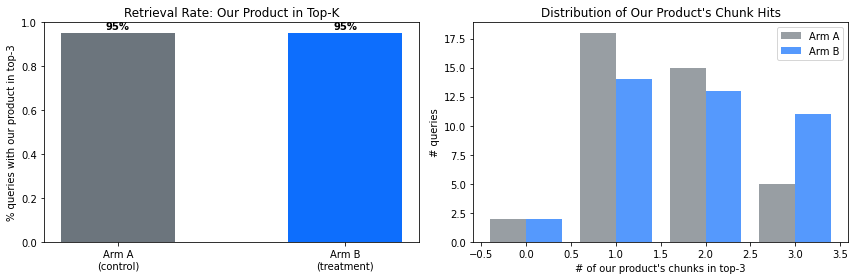

Saved → data/results/retrieval_diagnostic.png


In [12]:
import matplotlib.pyplot as plt

top_k = config["top_k"]
a_counts, b_counts = [], []

for q in queries:
    q_emb = embed_model.encode([q["text"]])[0]
    a_hits = sum(1 for chunk, _ in search(index_a, q_emb, top_k=top_k) if chunk.doc_id == "our_product")
    b_hits = sum(1 for chunk, _ in search(index_b, q_emb, top_k=top_k) if chunk.doc_id == "our_product")
    a_counts.append(a_hits)
    b_counts.append(b_hits)

a_rate = sum(1 for x in a_counts if x > 0) / len(queries)
b_rate = sum(1 for x in b_counts if x > 0) / len(queries)

print(f"Our product appears in top-{top_k} retrieved chunks:")
print(f"  Arm A (control)  : {a_rate:.0%} of queries")
print(f"  Arm B (treatment): {b_rate:.0%} of queries")
lift = (b_rate - a_rate) / a_rate if a_rate > 0 else float("nan")
print(f"  Retrieval-level lift: {lift:+.0%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: retrieval rate per arm
axes[0].bar(["Arm A\n(control)", "Arm B\n(treatment)"], [a_rate, b_rate],
            color=["#6c757d", "#0d6efd"], width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel(f"% queries with our product in top-{top_k}")
axes[0].set_title("Retrieval Rate: Our Product in Top-K")
for i, v in enumerate([a_rate, b_rate]):
    axes[0].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Histogram: how many of our product's chunks were retrieved per query
axes[1].hist([a_counts, b_counts], bins=[-0.5, 0.5, 1.5, 2.5, 3.5],
             label=["Arm A", "Arm B"], color=["#6c757d", "#0d6efd"], alpha=0.7)
axes[1].set_xlabel(f"# of our product's chunks in top-{top_k}")
axes[1].set_ylabel("# queries")
axes[1].set_title("Distribution of Our Product's Chunk Hits")
axes[1].legend()

plt.tight_layout()
plt.savefig("data/results/retrieval_diagnostic.png", dpi=150)
plt.show()
print("Saved → data/results/retrieval_diagnostic.png")

## 8. Statistical Analysis of Experiment Results

Now that we have 400 trials in `results.csv`, we work through the statistics step by step.

**What we're asking:** Did AEO-optimized content (Arm B) get recommended more often than control (Arm A)? And if there's a difference, is it real or just noise?

**The four tools we'll use:**
1. **Raw rates + lift** — the simplest possible answer
2. **Two-proportion z-test** — is the difference statistically significant? (naive version)
3. **Bootstrap CI** — what's the plausible *range* of true lift?
4. **Paired t-test** — the rigorous version that accounts for query-to-query variation
5. **Power analysis** — how many queries would we *need* to be confident?

In [13]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Load all 400 trial results
results = []
with open("data/results/results.csv") as f:
    results = list(csv.DictReader(f))

print(f"Total rows: {len(results)}")
print(f"\nFirst 3 rows (to see the schema):")
for r in results[:3]:
    print(f"  {dict(r)}")

# Split by arm and extract the binary outcome (recommended = 1 or 0)
arm_a = [r for r in results if r["arm"] == "A"]
arm_b = [r for r in results if r["arm"] == "B"]

outcomes_a = np.array([int(r["recommended"]) for r in arm_a])
outcomes_b = np.array([int(r["recommended"]) for r in arm_b])

print(f"\nArm A: {len(outcomes_a)} trials")
print(f"Arm B: {len(outcomes_b)} trials")

Total rows: 400

First 3 rows (to see the schema):
  {'query_id': 'q01', 'arm': 'A', 'repeat': '1', 'recommended': '1', 'position': '1', 'accepted': '1', 'reasoning': "The answer explicitly names TaskFlow Pro and frames it as 'the best project management tool for small teams,' making it the first and primary recommendation."}
  {'query_id': 'q01', 'arm': 'B', 'repeat': '1', 'recommended': '1', 'position': '1', 'accepted': '1', 'reasoning': "The answer explicitly names 'TaskFlow Pro' and frames it as a recommended choice ('strong choice', 'specifically designed for small teams') as the first and primary product recommendation."}
  {'query_id': 'q01', 'arm': 'A', 'repeat': '2', 'recommended': '1', 'position': '1', 'accepted': '1', 'reasoning': "The answer explicitly names 'TaskFlow Pro' by its exact name and frames it as 'the best project management tool for small teams' and 'the recommended choice,' making it the first and primary recommendation."}

Arm A: 200 trials
Arm B: 200 trials


### Step 1 — Raw rates and lift

**What is lift?**

Lift is just the relative change in recommendation rate between B and A:

```
lift = (rate_B - rate_A) / rate_A
```

If rate_A = 50% and rate_B = 60%, lift = (0.60 - 0.50) / 0.50 = **+20%**.

Why relative instead of absolute? Because a +10 percentage-point improvement means something very different at a 5% baseline (doubling the rate) vs a 50% baseline (modest improvement). Relative lift puts both on the same scale.

The problem with raw lift: it's a point estimate with no uncertainty. It tells you *what happened in this sample*, not what would happen if you ran it again.

RAW RECOMMENDATION RATES
  Arm A (control)   : 107/200 = 53.5%
  Arm B (treatment) : 96/200 = 48.0%

  Absolute diff     : -5.5% percentage points
  Relative lift     : -10.3%

  Interpretation: B was recommended 10.3% less often than A


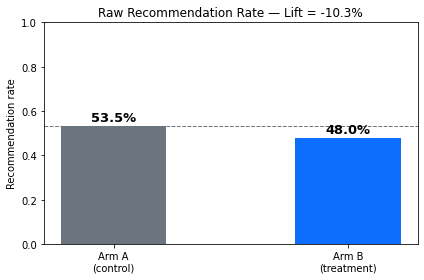

In [14]:
# --- Compute raw rates and lift by hand ---

n_a, n_b = len(outcomes_a), len(outcomes_b)
cited_a, cited_b = outcomes_a.sum(), outcomes_b.sum()

rate_a = cited_a / n_a
rate_b = cited_b / n_b
lift   = (rate_b - rate_a) / rate_a

print("RAW RECOMMENDATION RATES")
print("=" * 40)
print(f"  Arm A (control)   : {cited_a}/{n_a} = {rate_a:.1%}")
print(f"  Arm B (treatment) : {cited_b}/{n_b} = {rate_b:.1%}")
print(f"\n  Absolute diff     : {rate_b - rate_a:+.1%} percentage points")
print(f"  Relative lift     : {lift:+.1%}")
print(f"\n  Interpretation: B was recommended {abs(lift):.1%} {'more' if lift > 0 else 'less'} often than A")

# Visual
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Arm A\n(control)", "Arm B\n(treatment)"],
              [rate_a, rate_b], color=["#6c757d", "#0d6efd"], width=0.45)
ax.set_ylim(0, 1)
ax.set_ylabel("Recommendation rate")
ax.set_title(f"Raw Recommendation Rate — Lift = {lift:+.1%}")
for bar, val in zip(bars, [rate_a, rate_b]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.1%}", ha="center", fontsize=13, fontweight="bold")
ax.axhline(rate_a, color="#6c757d", linestyle="--", linewidth=1, label="Arm A baseline")
plt.tight_layout()
plt.savefig("data/results/fig_raw_rates.png", dpi=150)
plt.show()

### Step 2 — Two-proportion z-test (the naive significance test)

**What question does it answer?**

"If both arms actually had the *same* true recommendation rate, how likely is it that we'd see a difference this large just by chance?"

That probability is the **p-value**. If p < 0.05 we say the result is statistically significant at the 5% level — meaning we'd only see a gap this big 1 in 20 times under pure noise.

**How it works (the intuition):**

Each trial is a coin flip: recommended (1) or not (0). If we flip 200 coins for arm A and 200 for arm B, and the coins have the same true probability, the difference in counts will still vary just due to randomness. The z-test measures *how many standard deviations* the observed difference is away from zero:

```
z = (rate_B - rate_A) / standard_error
```

A z near 0 → difference is well within noise. A z beyond ±2 → difference is surprising under the null.

**Why it's called "naive":**

It assumes all 200 trials per arm are independent. But our trials aren't — we ran the same 40 queries 5 times each. Repeats from the same query are correlated (an easy query stays easy across repeats). This inflates our effective sample size and can make results look more significant than they are. The paired test (Step 4) fixes this.

/Users/shubhisaxena/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shubhisaxena/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


TWO-PROPORTION Z-TEST
  rate_A = 0.5350   rate_B = 0.4800
  difference = -0.0550
  standard error (SE) = 0.0499

  z (by hand)      = (rate_B - rate_A) / SE
                   = -0.0550 / 0.0499
                   = -1.102

  p-value (two-sided) = 0.2713

  Verdict: NOT significant at alpha=0.05

  Plain English: Under the null hypothesis (no true difference),
  we'd see a gap this large 27.1% of the time just by chance.
  That's not surprising enough to rule out chance.


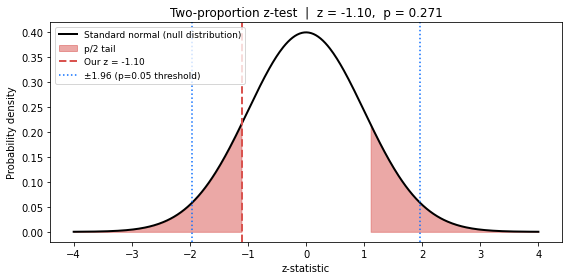


The RED shaded area IS the p-value — the probability of seeing |z| this extreme under the null.


In [15]:
from statsmodels.stats.proportion import proportions_ztest

# Build the z-statistic by hand so you can see every step
se = np.sqrt(rate_a * (1 - rate_a) / n_a + rate_b * (1 - rate_b) / n_b)
z_manual = (rate_b - rate_a) / se

# Use statsmodels to get the two-sided p-value
z_lib, p_lib = proportions_ztest([cited_b, cited_a], [n_b, n_a])

print("TWO-PROPORTION Z-TEST")
print("=" * 40)
print(f"  rate_A = {rate_a:.4f}   rate_B = {rate_b:.4f}")
print(f"  difference = {rate_b - rate_a:+.4f}")
print(f"  standard error (SE) = {se:.4f}")
print(f"\n  z (by hand)      = (rate_B - rate_A) / SE")
print(f"                   = {rate_b - rate_a:.4f} / {se:.4f}")
print(f"                   = {z_manual:.3f}")
print(f"\n  p-value (two-sided) = {p_lib:.4f}")
print(f"\n  Verdict: {'SIGNIFICANT at alpha=0.05' if p_lib < 0.05 else 'NOT significant at alpha=0.05'}")
print(f"\n  Plain English: Under the null hypothesis (no true difference),")
print(f"  we'd see a gap this large {p_lib:.1%} of the time just by chance.")
print(f"  That's {'surprising' if p_lib < 0.05 else 'not surprising enough to rule out chance'}.")

# Visualise the z-distribution to make the p-value concrete
from scipy.stats import norm
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, norm.pdf(x), "k-", linewidth=2, label="Standard normal (null distribution)")
ax.fill_between(x, norm.pdf(x), where=(x <= -abs(z_manual)), color="#d9534f", alpha=0.5, label=f"p/2 tail")
ax.fill_between(x, norm.pdf(x), where=(x >= abs(z_manual)),  color="#d9534f", alpha=0.5)
ax.axvline(z_manual, color="#d9534f", linestyle="--", linewidth=2, label=f"Our z = {z_manual:.2f}")
ax.axvline(-1.96, color="#0d6efd", linestyle=":", linewidth=1.5, label="±1.96 (p=0.05 threshold)")
ax.axvline( 1.96, color="#0d6efd", linestyle=":", linewidth=1.5)
ax.set_xlabel("z-statistic")
ax.set_ylabel("Probability density")
ax.set_title(f"Two-proportion z-test  |  z = {z_manual:.2f},  p = {p_lib:.3f}")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("data/results/fig_ztest.png", dpi=150)
plt.show()
print("\nThe RED shaded area IS the p-value — the probability of seeing |z| this extreme under the null.")

### Step 3 — Bootstrap confidence interval on lift

**Why not just use the point estimate?**

The −10.3% lift is what we *observed*, but with only 200 trials per arm the estimate is noisy. The true lift could be anywhere in a wide range. A confidence interval quantifies that range.

**How bootstrap works (the analogy):**

Imagine you have a bag of 200 marbles, some painted "recommended" (1) and the rest "not recommended" (0). You draw 200 marbles *with replacement* (so the same marble can appear twice), compute the recommendation rate, put them back, and repeat 10,000 times. Each resampled bag gives you one possible "what if the experiment ran slightly differently" rate. The spread of those 10,000 rates is your sampling distribution.

You then compute lift for each of the 10,000 paired (A, B) resamplings and take the 2.5th and 97.5th percentiles — those are your 95% confidence interval bounds.

**Why bootstrap instead of a formula?**

For proportions you could derive a formula. But bootstrap works for *any* statistic — lift, median, ratio of rates — without needing to know the distribution. It's the Swiss Army knife of uncertainty quantification.

BOOTSTRAP CONFIDENCE INTERVAL
  Observed lift       : -10.3%
  95% CI              : [-26.2%,  +9.3%]

  CI crosses zero?    : YES — cannot rule out zero effect

  Reading the CI: the true lift is plausibly anywhere
  from -26.2% to +9.3%.
  Because 0 is inside this range, we cannot claim a
  statistically significant effect in either direction.


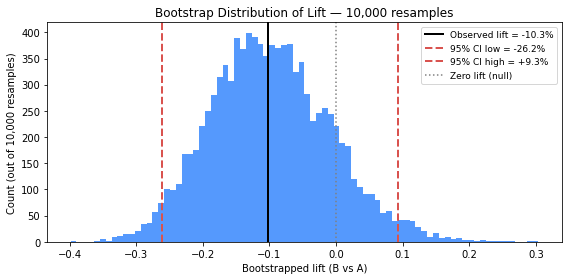


The spread of this distribution IS the uncertainty in our estimate.


In [16]:
rng = np.random.default_rng(42)   # fixed seed so you get the same result every run
n_iters = 10_000

bootstrapped_lifts = []
for _ in range(n_iters):
    # Resample each arm WITH REPLACEMENT — same length, different composition each time
    sample_a = rng.choice(outcomes_a, size=len(outcomes_a), replace=True).mean()
    sample_b = rng.choice(outcomes_b, size=len(outcomes_b), replace=True).mean()
    if sample_a > 0:                      # avoid divide-by-zero in degenerate resamples
        bootstrapped_lifts.append((sample_b - sample_a) / sample_a)

bootstrapped_lifts = np.array(bootstrapped_lifts)
ci_low  = np.percentile(bootstrapped_lifts, 2.5)
ci_high = np.percentile(bootstrapped_lifts, 97.5)
observed_lift = (rate_b - rate_a) / rate_a

print("BOOTSTRAP CONFIDENCE INTERVAL")
print("=" * 40)
print(f"  Observed lift       : {observed_lift:+.1%}")
print(f"  95% CI              : [{ci_low:+.1%},  {ci_high:+.1%}]")
print(f"\n  CI crosses zero?    : {'YES — cannot rule out zero effect' if ci_low < 0 < ci_high else 'NO'}")
print(f"\n  Reading the CI: the true lift is plausibly anywhere")
print(f"  from {ci_low:+.1%} to {ci_high:+.1%}.")
print(f"  Because 0 is inside this range, we cannot claim a")
print(f"  statistically significant effect in either direction.")

# Plot the bootstrap distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bootstrapped_lifts, bins=80, color="#0d6efd", alpha=0.7, edgecolor="none")
ax.axvline(observed_lift, color="black",   linestyle="-",  linewidth=2, label=f"Observed lift = {observed_lift:+.1%}")
ax.axvline(ci_low,        color="#d9534f", linestyle="--", linewidth=2, label=f"95% CI low = {ci_low:+.1%}")
ax.axvline(ci_high,       color="#d9534f", linestyle="--", linewidth=2, label=f"95% CI high = {ci_high:+.1%}")
ax.axvline(0,             color="gray",    linestyle=":",  linewidth=1.5, label="Zero lift (null)")
ax.set_xlabel("Bootstrapped lift (B vs A)")
ax.set_ylabel("Count (out of 10,000 resamples)")
ax.set_title("Bootstrap Distribution of Lift — 10,000 resamples")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("data/results/fig_bootstrap_ci.png", dpi=150)
plt.show()
print("\nThe spread of this distribution IS the uncertainty in our estimate.")

### Step 4 — Paired t-test (the rigorous version)

**Why do we need a different test?**

The z-test above treated all 200 trials per arm as 200 independent coin flips. But they're not — we ran the same 40 queries 5 times each. This matters because:

- Query q01 ("best PM tool for small teams") is easy: TaskFlow Pro gets recommended almost every time regardless of arm.
- Query q02 ("free PM software for startups") is harder: it rarely gets recommended.

These *query-level differences* are not what we're trying to measure. We want to know: for a given query, did B do *better than A on that same query*? That's a within-query comparison, not a between-trial comparison.

**The fix:**

Aggregate all 5 repeats per query into a single rate: `rate(q, arm) = sum(recommended) / 5`. Now we have 40 paired measurements:

```
query q01: rate_A = 1.0,  rate_B = 1.0,  diff = 0.0
query q04: rate_A = 1.0,  rate_B = 0.0,  diff = -1.0
query q37: rate_A = 0.0,  rate_B = 1.0,  diff = +1.0
...
```

The **paired t-test** tests whether the *mean of these 40 differences* is significantly different from zero. Because each query is compared to itself across both arms, the between-query noise cancels out — you're left with a much cleaner signal.

In [17]:
from scipy import stats as sp

# Step 1: aggregate repeats → per-query rates
by_query_a = defaultdict(list)
by_query_b = defaultdict(list)
for r in results:
    if r["arm"] == "A":
        by_query_a[r["query_id"]].append(int(r["recommended"]))
    else:
        by_query_b[r["query_id"]].append(int(r["recommended"]))

query_ids = sorted(by_query_a.keys())
rate_a_per_q = np.array([np.mean(by_query_a[q]) for q in query_ids])
rate_b_per_q = np.array([np.mean(by_query_b[q]) for q in query_ids])
diffs = rate_b_per_q - rate_a_per_q   # positive = B better, negative = A better

# Step 2: show the per-query breakdown
print(f"PER-QUERY RATES (40 paired measurements)\n{'─'*55}")
print(f"{'Query':<8}  {'rate_A':>8}  {'rate_B':>8}  {'diff':>8}  winner")
print(f"{'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*6}")
for qid, ra, rb, d in zip(query_ids, rate_a_per_q, rate_b_per_q, diffs):
    win = "B>A ▲" if d > 0 else ("A>B ▼" if d < 0 else "tie")
    print(f"  {qid:<6}  {ra:>8.2f}  {rb:>8.2f}  {d:>+8.2f}  {win}")

mean_diff = diffs.mean()
print(f"\n  Mean difference (B - A): {mean_diff:+.4f}")
print(f"  B won on {(diffs > 0).sum()} queries, A won on {(diffs < 0).sum()}, tied on {(diffs == 0).sum()}")

PER-QUERY RATES (40 paired measurements)
───────────────────────────────────────────────────────
Query       rate_A    rate_B      diff  winner
────────  ────────  ────────  ────────  ──────
  q01         1.00      1.00     +0.00  tie
  q02         0.00      0.00     +0.00  tie
  q03         0.40      0.00     -0.40  A>B ▼
  q04         1.00      0.00     -1.00  A>B ▼
  q05         1.00      1.00     +0.00  tie
  q06         0.80      1.00     +0.20  B>A ▲
  q07         0.00      0.00     +0.00  tie
  q08         1.00      1.00     +0.00  tie
  q09         1.00      1.00     +0.00  tie
  q10         0.00      0.00     +0.00  tie
  q11         1.00      1.00     +0.00  tie
  q12         1.00      1.00     +0.00  tie
  q13         1.00      1.00     +0.00  tie
  q14         1.00      1.00     +0.00  tie
  q15         1.00      1.00     +0.00  tie
  q16         0.00      0.00     +0.00  tie
  q17         1.00      1.00     +0.00  tie
  q18         0.00      0.00     +0.00  tie
  q19      

PAIRED T-TEST
  Mean rate A (across queries) : 0.535
  Mean rate B (across queries) : 0.480
  Mean difference (B - A)      : -0.055
  Std of differences           : 0.359

  t-statistic : -0.968
  p-value     : 0.3391

  Verdict: NOT significant at alpha=0.05


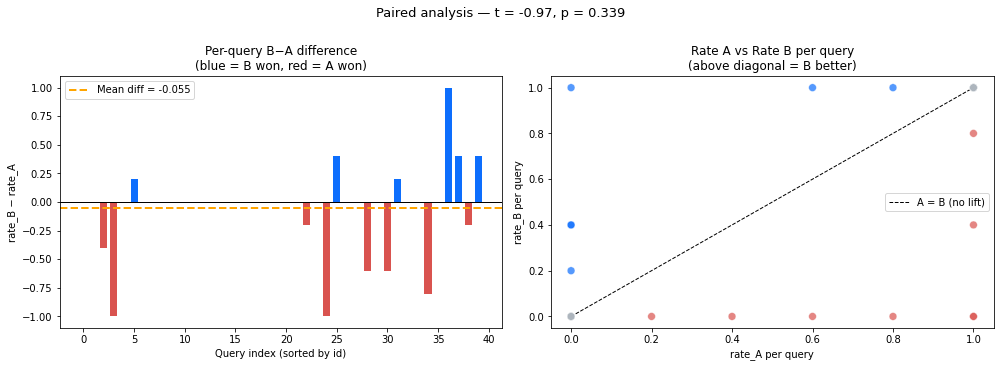

LEFT chart: each bar is one query. The mean of these bars is what the t-test tests.
RIGHT chart: each dot is one query. Dots above the dashed line → B outperformed A on that query.


In [18]:
# Step 3: run the paired t-test and visualise the differences
t_stat, p_val = sp.ttest_rel(rate_b_per_q, rate_a_per_q)

print("PAIRED T-TEST")
print("=" * 40)
print(f"  Mean rate A (across queries) : {rate_a_per_q.mean():.3f}")
print(f"  Mean rate B (across queries) : {rate_b_per_q.mean():.3f}")
print(f"  Mean difference (B - A)      : {mean_diff:+.3f}")
print(f"  Std of differences           : {diffs.std(ddof=1):.3f}")
print(f"\n  t-statistic : {t_stat:.3f}")
print(f"  p-value     : {p_val:.4f}")
print(f"\n  Verdict: {'SIGNIFICANT at alpha=0.05' if p_val < 0.05 else 'NOT significant at alpha=0.05'}")

# Plot 1: per-query diff as a waterfall chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#0d6efd" if d > 0 else "#d9534f" if d < 0 else "#adb5bd" for d in diffs]
axes[0].bar(range(len(diffs)), diffs, color=colors, width=0.7)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axhline(mean_diff, color="orange", linestyle="--", linewidth=2, label=f"Mean diff = {mean_diff:+.3f}")
axes[0].set_xlabel("Query index (sorted by id)")
axes[0].set_ylabel("rate_B − rate_A")
axes[0].set_title("Per-query B−A difference\n(blue = B won, red = A won)")
axes[0].legend()

# Plot 2: scatter rate_A vs rate_B per query (above diagonal = B better)
axes[1].scatter(rate_a_per_q, rate_b_per_q, alpha=0.7, s=60,
                c=colors, edgecolors="white", linewidths=0.5, zorder=3)
diag = np.linspace(0, 1, 100)
axes[1].plot(diag, diag, "k--", linewidth=1, label="A = B (no lift)")
axes[1].set_xlabel("rate_A per query")
axes[1].set_ylabel("rate_B per query")
axes[1].set_title("Rate A vs Rate B per query\n(above diagonal = B better)")
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.suptitle(f"Paired analysis — t = {t_stat:.2f}, p = {p_val:.3f}", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("data/results/fig_paired_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("LEFT chart: each bar is one query. The mean of these bars is what the t-test tests.")
print("RIGHT chart: each dot is one query. Dots above the dashed line → B outperformed A on that query.")

### Step 5 — Power analysis

**The most important concept in this whole project.**

A non-significant result (p > 0.05) means one of two things:
1. There is no real effect (the null is true)
2. There IS an effect, but our sample was too small to detect it

Power analysis tells us which one is more likely — and how many queries we'd need to be able to tell them apart.

**Key terms:**
- **α (alpha)** = false positive rate (we set this at 0.05)
- **Power (1-β)** = probability of detecting a real effect when one exists (we target 80%)
- **MDE** = Minimum Detectable Effect — the smallest lift we care about detecting (+20% relative here)
- **Required n** = the sample size per arm needed to achieve the target power

**The curve below** shows how power grows as you add more queries. At 40 queries, we have very little power. At ~963 we reach 80%. This is why we call our run a "pilot" — it was designed to demonstrate methodology, not produce a publishable conclusion.

POWER ANALYSIS
  Baseline rate         : 30%
  Treatment rate (MDE)  : 36%  (= baseline × 120%)
  Effect size (Cohen h) : 0.1277
  Required n / arm      : 963
  Our actual n / arm    : 40 queries

  At n=40, our power is approximately:
  8.8%  — meaning we'd miss a 20% relative lift
  91% of the time even if it's real.


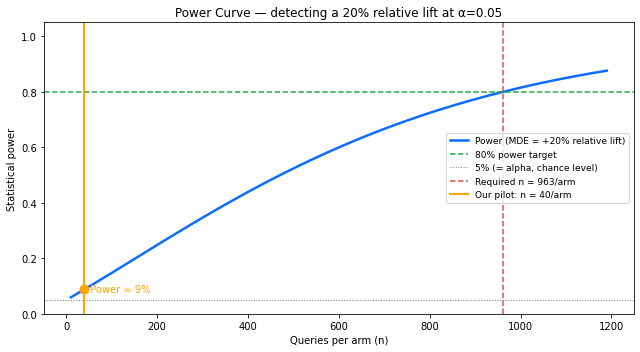

In [19]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

baseline  = 0.30    # pre-registered baseline rate
mde_rel   = 0.20    # detect a 20% relative lift
alpha     = 0.05
target_pw = 0.80

p1 = baseline
p2 = baseline * (1 + mde_rel)
effect_size = proportion_effectsize(p2, p1)

required_n = NormalIndPower().solve_power(
    effect_size=effect_size, alpha=alpha, power=target_pw, alternative="two-sided"
)

print("POWER ANALYSIS")
print("=" * 40)
print(f"  Baseline rate         : {p1:.0%}")
print(f"  Treatment rate (MDE)  : {p2:.0%}  (= baseline × {1+mde_rel:.0%})")
print(f"  Effect size (Cohen h) : {effect_size:.4f}")
print(f"  Required n / arm      : {int(np.ceil(required_n))}")
print(f"  Our actual n / arm    : 40 queries")
print(f"\n  At n=40, our power is approximately:")

power_at_40 = NormalIndPower().solve_power(
    effect_size=effect_size, alpha=alpha, nobs1=40, alternative="two-sided"
)
print(f"  {power_at_40:.1%}  — meaning we'd miss a {mde_rel:.0%} relative lift")
print(f"  {1-power_at_40:.0%} of the time even if it's real.")

# Power curve
ns = np.arange(10, 1200, 10)
powers = [NormalIndPower().solve_power(
    effect_size=effect_size, alpha=alpha, nobs1=n, alternative="two-sided") for n in ns]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, powers, color="#0d6efd", linewidth=2.5, label=f"Power (MDE = +{mde_rel:.0%} relative lift)")
ax.axhline(0.80, color="#28a745", linestyle="--", linewidth=1.5, label="80% power target")
ax.axhline(0.05, color="gray",    linestyle=":",  linewidth=1,   label="5% (= alpha, chance level)")
ax.axvline(required_n, color="#d9534f", linestyle="--", linewidth=1.5,
           label=f"Required n = {int(np.ceil(required_n))}/arm")
ax.axvline(40, color="orange", linestyle="-", linewidth=2, label="Our pilot: n = 40/arm")
ax.scatter([40], [power_at_40], color="orange", s=80, zorder=5)
ax.annotate(f"  Power ≈ {power_at_40:.0%}", xy=(40, power_at_40),
            fontsize=10, va="center", color="orange")
ax.set_xlabel("Queries per arm (n)")
ax.set_ylabel("Statistical power")
ax.set_title(f"Power Curve — detecting a {mde_rel:.0%} relative lift at α={alpha}")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("data/results/fig_power_curve.png", dpi=150)
plt.show()

In [20]:
# Final summary table — all results in one place
from statsmodels.stats.proportion import proportions_ztest

_, p_z = proportions_ztest([cited_b, cited_a], [n_b, n_a])
t_stat, p_t = sp.ttest_rel(rate_b_per_q, rate_a_per_q)

print("=" * 60)
print("COMPLETE STATISTICAL SUMMARY")
print("=" * 60)
print(f"\n  Arm A recommendation rate : {rate_a:.1%}  ({cited_a}/{n_a} trials)")
print(f"  Arm B recommendation rate : {rate_b:.1%}  ({cited_b}/{n_b} trials)")
print(f"  Raw lift                  : {observed_lift:+.1%}")
print(f"  Bootstrap 95% CI on lift  : [{ci_low:+.1%},  {ci_high:+.1%}]")
print(f"\n  Two-proportion z-test     : p = {p_z:.4f}  {'✗ NOT sig.' if p_z >= 0.05 else '✓ SIGNIFICANT'}")
print(f"  Paired t-test (rigorous)  : p = {p_t:.4f}  {'✗ NOT sig.' if p_t >= 0.05 else '✓ SIGNIFICANT'}")
print(f"\n  Power at n=40/arm         : {power_at_40:.0%}")
print(f"  Required n for 80% power  : {int(np.ceil(required_n))}/arm")
print(f"\n  Conclusion:")
print(f"  The observed lift of {observed_lift:+.1%} is not statistically significant")
print(f"  (p = {p_t:.2f} > 0.05). The 95% CI [{ci_low:+.1%}, {ci_high:+.1%}] includes")
print(f"  zero, so we cannot rule out chance. With only 40 queries/arm")
print(f"  (power ≈ {power_at_40:.0%}), this pilot was designed to demonstrate")
print(f"  methodology — a powered study would need ~{int(np.ceil(required_n))} queries/arm.")
print("=" * 60)

COMPLETE STATISTICAL SUMMARY

  Arm A recommendation rate : 53.5%  (107/200 trials)
  Arm B recommendation rate : 48.0%  (96/200 trials)
  Raw lift                  : -10.3%
  Bootstrap 95% CI on lift  : [-26.2%,  +9.3%]

  Two-proportion z-test     : p = 0.2713  ✗ NOT sig.
  Paired t-test (rigorous)  : p = 0.3391  ✗ NOT sig.

  Power at n=40/arm         : 9%
  Required n for 80% power  : 963/arm

  Conclusion:
  The observed lift of -10.3% is not statistically significant
  (p = 0.34 > 0.05). The 95% CI [-26.2%, +9.3%] includes
  zero, so we cannot rule out chance. With only 40 queries/arm
  (power ≈ 9%), this pilot was designed to demonstrate
  methodology — a powered study would need ~963 queries/arm.
